# Candidate Pool — Exploratory Data Analysis
Load the entire `candidates.jsonl` into memory for interactive exploration.

In [1]:
import json
import pandas as pd
from pathlib import Path

CANDIDATES_PATH = Path('challenge_dataset/candidates.jsonl') #the data directory has not been committed to Github due to its size.

# Read every line into a list of dicts
records = []
with CANDIDATES_PATH.open('r', encoding='utf-8') as fh:
    for line in fh:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f'Loaded {len(records):,} candidates')
print(f'Keys in records: {list(records[0].keys())}')

Loaded 100,000 candidates
Keys in records: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']


In [2]:
# Inspecting dictionary structure.
import pprint
pprint.pprint(records[0])

{'candidate_id': 'CAND_0000001',
 'career_history': [{'company': 'Mindtree',
                     'company_size': '10001+',
                     'description': 'Implemented streaming data pipelines on '
                                    'Kafka and Spark Streaming for a real-time '
                                    'user-activity processing platform. '
                                    'Designed the schema-registry integration, '
                                    'the watermark/state management approach, '
                                    'and the deduplication logic for '
                                    'late-arriving events. Worked closely with '
                                    'the data science team to make sure '
                                    'feature pipelines aligned with what their '
                                    'models needed. Most of my career has been '
                                    'data engineering, with some adjacent ML '
              

<h3> Inspect Titles </h3>

In [3]:
# Count of all unique current_title values across the dataset
from collections import Counter

title_counts = Counter(
    c['profile'].get('current_title', '').strip()
    for c in records
    if c.get('profile', {}).get('current_title')
)

# Convert to a sorted DataFrame (most common first)
df_titles = (
    pd.DataFrame(title_counts.most_common(), columns=['Title', 'Count'])
    .reset_index(drop=True)
)
df_titles.index += 1

print(f'Unique titles: {len(df_titles):,}')
df_titles.head(len(df_titles))


Unique titles: 47


,Title,Count
1,Business Analyst,5833
2,HR Manager,5830
3,Mechanical Engineer,5791
4,Accountant,5764
5,Project Manager,5754
6,Customer Support,5750
7,Operations Manager,5744
8,Content Writer,5727
9,Sales Executive,5713
10,Civil Engineer,5702


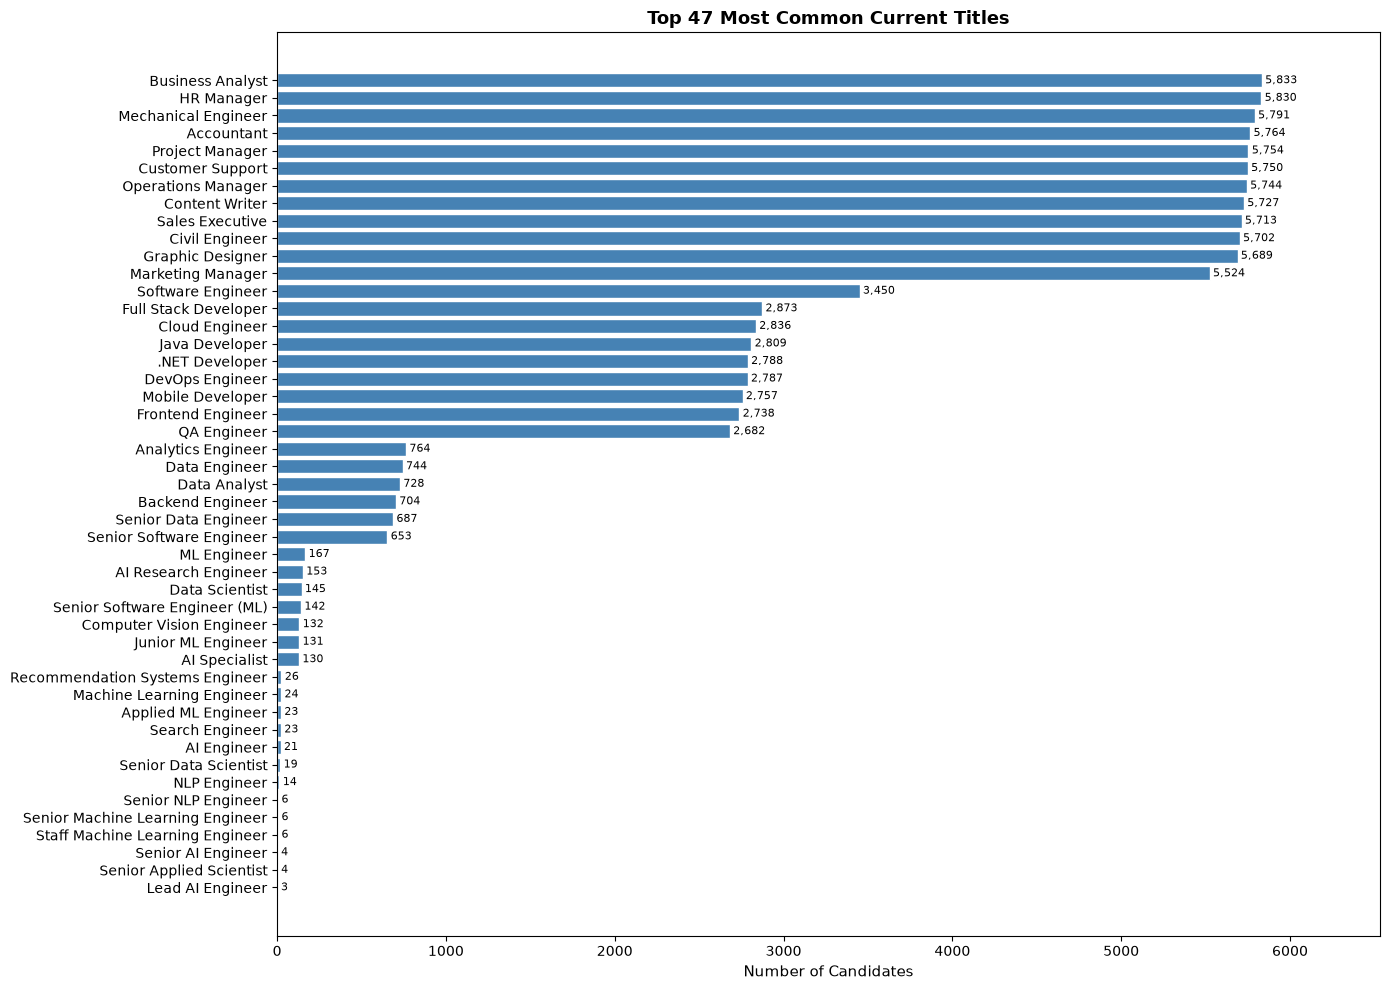

In [4]:
#Bar chart:most common current titles
import matplotlib.pyplot as plt

TOP = 47
top_df = df_titles.head(TOP)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(top_df['Title'][::-1], top_df['Count'][::-1], color='steelblue', edgecolor='white')

# Label each bar with its count
for bar, val in zip(bars, top_df['Count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

ax.set_xlabel('Number of Candidates', fontsize=11)
ax.set_title(f'Top {TOP} Most Common Current Titles', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_df['Count'].max() * 1.12)
plt.tight_layout()
plt.show()


In [32]:
#Inspecting career history

rows = []
for c in records:
    cid     = c.get('candidate_id', '')
    profile = c.get('profile', {}) or {}
    career  = c.get('career_history', []) or []

    current = profile.get('current_title', '')

    # Sort jobs by start_date descending so index 0 = most recent previous job
    past_jobs = sorted(
        [j for j in career if not j.get('is_current', False) and j.get('start_date')],
        key=lambda j: j['start_date'],
        reverse=True
    )

    prev1 = past_jobs[0]['title'] if len(past_jobs) > 0 else ''
    prev2 = past_jobs[1]['title'] if len(past_jobs) > 1 else ''

    rows.append({
        'candidate_id'     : cid,
        'current_title'    : current,
        'previous_title_1' : prev1,
        'previous_title_2' : prev2,
    })

df_career = (
    pd.DataFrame(rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

pd.set_option('display.max_rows', 500)
print(f'{len(df_career):,} candidates')
df_career


100,000 candidates


,candidate_id,current_title,previous_title_1,previous_title_2
0,CAND_0000001,Backend Engineer,Analytics Engineer,
1,CAND_0000002,Operations Manager,Operations Manager,Marketing Manager
2,CAND_0000003,Customer Support,,
3,CAND_0000004,Marketing Manager,Operations Manager,Business Analyst
4,CAND_0000005,Accountant,HR Manager,HR Manager
...,...,...,...,...
99995,CAND_0099996,Operations Manager,Civil Engineer,Mechanical Engineer
99996,CAND_0099997,Mechanical Engineer,Content Writer,Graphic Designer
99997,CAND_0099998,Analytics Engineer,Analytics Engineer,Software Engineer
99998,CAND_0099999,.NET Developer,Full Stack Developer,


In [33]:
df_career.head(20)

,candidate_id,current_title,previous_title_1,previous_title_2
0,CAND_0000001,Backend Engineer,Analytics Engineer,
1,CAND_0000002,Operations Manager,Operations Manager,Marketing Manager
2,CAND_0000003,Customer Support,,
3,CAND_0000004,Marketing Manager,Operations Manager,Business Analyst
4,CAND_0000005,Accountant,HR Manager,HR Manager
5,CAND_0000006,Business Analyst,Mechanical Engineer,
6,CAND_0000007,Civil Engineer,Mechanical Engineer,
7,CAND_0000008,Operations Manager,,
8,CAND_0000009,Mechanical Engineer,Content Writer,Customer Support
9,CAND_0000010,Data Engineer,,


<h3> Inspect Skills </h3>

In [6]:
from collections import Counter

skill_counts = Counter(
    s.get('name', '').strip()
    for c in records
    for s in c.get('skills', [])
    if s.get('name', '').strip()
)

all_skills = [skill for skill, count in skill_counts.most_common()]

print(f'Total unique skills: {len(all_skills)}\n')
for i, skill in enumerate(all_skills, 1):
    print(f'{i:>4}. {skill}')

Total unique skills: 133

   1. HTML
   2. Databricks
   3. Redux
   4. Terraform
   5. Angular
   6. Figma
   7. Salesforce CRM
   8. Vue.js
   9. Sales
  10. Accounting
  11. Agile
  12. Kafka
  13. Excel
  14. BigQuery
  15. CI/CD
  16. Project Management
  17. Airflow
  18. AWS
  19. Flask
  20. Scrum
  21. Illustrator
  22. Kubernetes
  23. ETL
  24. CSS
  25. Docker
  26. Next.js
  27. Apache Beam
  28. Java
  29. Go
  30. TypeScript
  31. JavaScript
  32. dbt
  33. REST APIs
  34. Spark
  35. Marketing
  36. Tally
  37. GraphQL
  38. Snowflake
  39. Webpack
  40. Six Sigma
  41. SEO
  42. SAP
  43. GCP
  44. PostgreSQL
  45. Rust
  46. Apache Flink
  47. gRPC
  48. Content Writing
  49. SQL
  50. Hadoop
  51. Redis
  52. Tailwind
  53. Photoshop
  54. FastAPI
  55. Microservices
  56. PowerPoint
  57. Spring Boot
  58. Data Pipelines
  59. Django
  60. MongoDB
  61. Node.js
  62. Azure
  63. React
  64. Hugging Face Transformers
  65. LangChain
  66. Information Retrieval
  67. 

In [ ]:
#Relevant skills for the JD


<h3> Inspecting Company diversity </h3>

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Count every company ever mentioned across all career history entries
company_counts = Counter(
    job.get('company', '').strip()
    for c in records
    for job in c.get('career_history', [])
    if job.get('company', '').strip()
)

df_companies = (
    pd.DataFrame(company_counts.most_common(), columns=['Company', 'Count'])
    .reset_index(drop=True)
)
df_companies.index += 1

print(f'Unique companies in dataset : {len(df_companies):,}')
print(f'Total company mentions      : {sum(company_counts.values()):,}')
df_companies.head(len(df_companies))


Unique companies in dataset : 63
Total company mentions      : 300,171


,Company,Count
1,Infosys,23722
2,Wipro,23682
3,Pied Piper,23614
4,Initech,23590
5,Wayne Enterprises,23556
6,Acme Corp,23546
7,Stark Industries,23524
8,Hooli,23509
9,TCS,23483
10,Globex Inc,23471


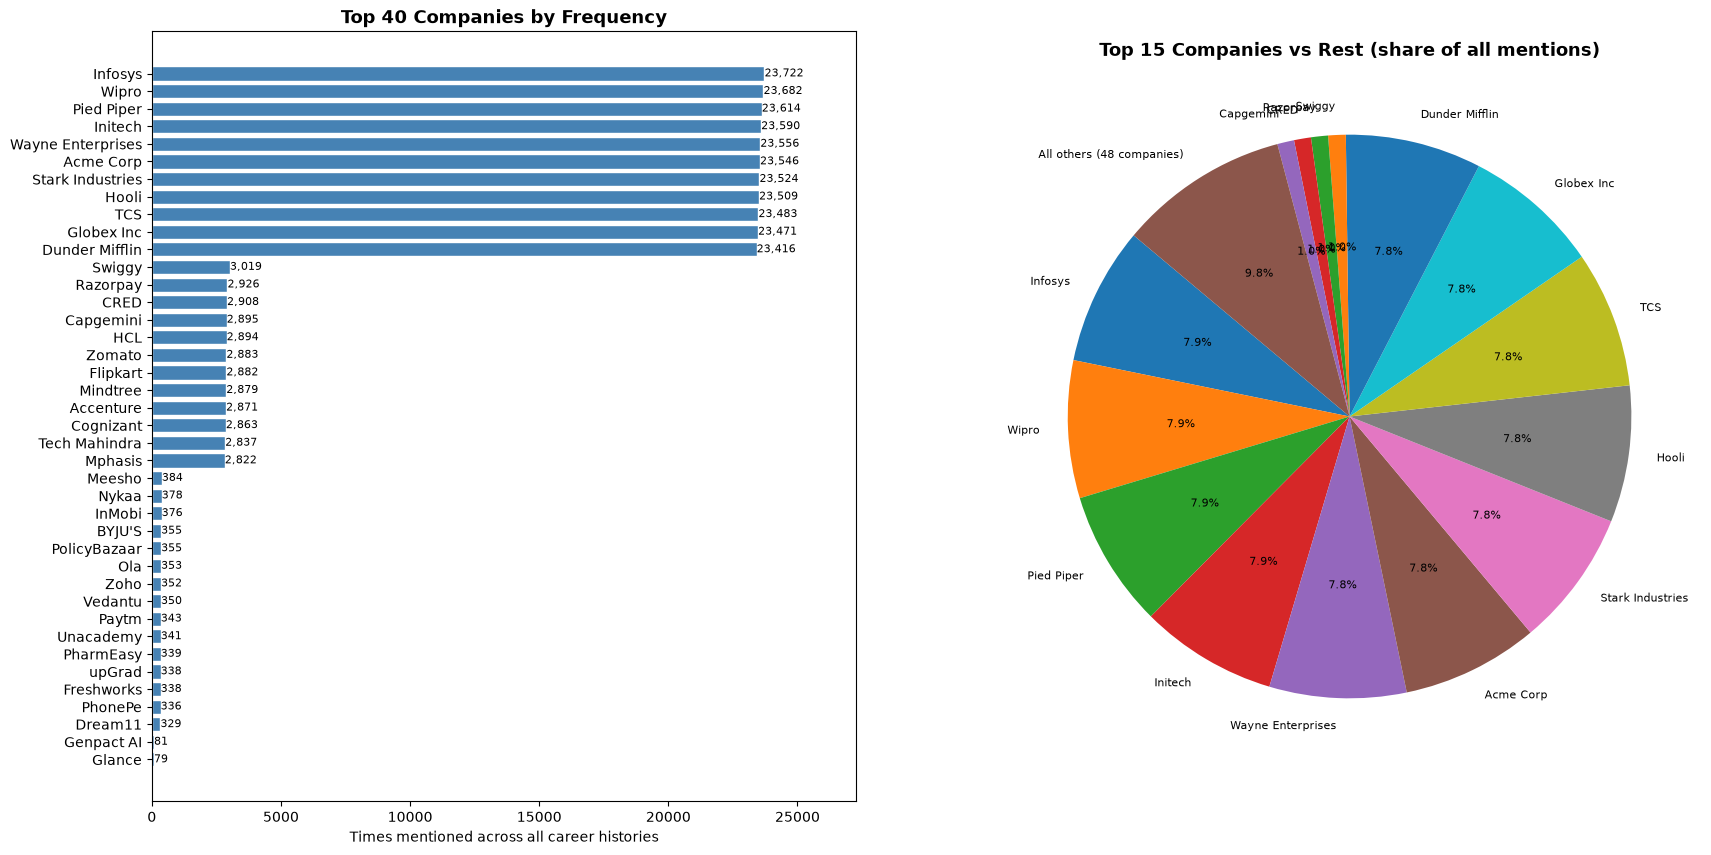

In [ ]:
TOP = 40
top_companies = df_companies.head(TOP)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# top 40 companies
bars = axes[0].barh(
    top_companies['Company'][::-1],
    top_companies['Count'][::-1],
    color='steelblue', edgecolor='white'
)
for bar, val in zip(bars, top_companies['Count'][::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=8)
axes[0].set_xlabel('Times mentioned across all career histories')
axes[0].set_title(f'Top {TOP} Companies by Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, top_companies['Count'].max() * 1.15)

#Pie chart: top 15 vs rest 
TOP_PIE = 15
pie_data  = list(top_companies['Count'][:TOP_PIE]) + [df_companies['Count'][TOP_PIE:].sum()]
pie_labels = list(top_companies['Company'][:TOP_PIE]) + [f'All others ({len(df_companies) - TOP_PIE:,} companies)']
axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title(f'Top {TOP_PIE} Companies vs Rest (share of all mentions)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [18]:
# list of companies.
all_companies = [company for company, count in company_counts.most_common()]
print(all_companies)


['Infosys', 'Wipro', 'Pied Piper', 'Initech', 'Wayne Enterprises', 'Acme Corp', 'Stark Industries', 'Hooli', 'TCS', 'Globex Inc', 'Dunder Mifflin', 'Swiggy', 'Razorpay', 'CRED', 'Capgemini', 'HCL', 'Zomato', 'Flipkart', 'Mindtree', 'Accenture', 'Cognizant', 'Tech Mahindra', 'Mphasis', 'Meesho', 'Nykaa', 'InMobi', "BYJU'S", 'PolicyBazaar', 'Ola', 'Zoho', 'Vedantu', 'Paytm', 'Unacademy', 'PharmEasy', 'upGrad', 'Freshworks', 'PhonePe', 'Dream11', 'Genpact AI', 'Glance', 'Rephrase.ai', 'Aganitha', 'Niramai', 'Saarthi.ai', 'Sarvam AI', 'Mad Street Den', 'Observe.AI', 'Krutrim', 'Wysa', 'Haptik', 'Verloop.io', 'Yellow.ai', 'Locobuzz', 'Google', 'Netflix', 'Amazon', 'Salesforce', 'Uber', 'Meta', 'Adobe', 'Microsoft', 'Apple', 'LinkedIn']


In [ ]:
#list of pure-consulting companies and fake companies. The JD asks us to avoid candidates who have only ever worked in pure consulting companies.
#  The following list is not exhaustive, but it should cover the most common consulting companies available in the dataset.

consulting_companies = ['Infosys', 'Wipro', 'TCS', 'Capgemini', 'HCL', 'Mindtree', 'Accenture', 'Cognizant', 'Tech Mahindra', 'Mphasis']
fictional_companies = ['Pied Piper', 'Initech', 'Wayne Enterprises', 'Stark Industries', 'Hooli', 'Dunder Mifflin']

#To figure-out --> [Globex Inc, Acme Corp] -> a real company or the fictional company from The Simpsons?

In [ ]:
#Create a dataframe to find out consulting_only candidates. 
consulting_set = {c.lower() for c in consulting_companies}

rows = []
for c in records:
    cid    = c.get('candidate_id', '')
    career = c.get('career_history', []) or []

    # Sort by start_date descending → most recent first
    sorted_jobs = sorted(
        [j for j in career if j.get('start_date')],
        key=lambda j: j['start_date'],
        reverse=True
    )

    all_companies = [j.get('company', '').strip() for j in sorted_jobs if j.get('company', '').strip()]

    company_n   = all_companies[0] if len(all_companies) > 0 else ''
    company_n1  = all_companies[1] if len(all_companies) > 1 else ''
    company_n2  = all_companies[2] if len(all_companies) > 2 else ''

    # consulting_only = True only if every company in the full history is a consulting firm
    if all_companies:
        consulting_only = all(co.lower() in consulting_set for co in all_companies)
    else:
        consulting_only = False

    rows.append({
        'candidate_id'   : cid,
        'company_n'      : company_n,
        'company_(n-1)'  : company_n1,
        'company_(n-2)'  : company_n2,
        'consulting_only': consulting_only,
    })

df_consulting = (
    pd.DataFrame(rows)
    .sort_values('candidate_id')
    .reset_index(drop=True)
)

print(f"Total candidates      : {len(df_consulting):,}")
print(f"Consulting-only (True): {df_consulting['consulting_only'].sum():,}")
print(f"Mixed/product  (False): {(~df_consulting['consulting_only']).sum():,}")
df_consulting

Total candidates      : 100,000
Consulting-only (True): 9,745
Mixed/product  (False): 90,255


,candidate_id,company_n,company_(n-1),company_(n-2),consulting_only
0,CAND_0000001,Mindtree,Dunder Mifflin,,False
1,CAND_0000002,Wipro,Wipro,Acme Corp,False
2,CAND_0000003,TCS,,,True
3,CAND_0000004,Dunder Mifflin,Infosys,Globex Inc,False
4,CAND_0000005,Stark Industries,Wipro,Initech,False
...,...,...,...,...,...
99995,CAND_0099996,Wipro,Hooli,Dunder Mifflin,False
99996,CAND_0099997,Hooli,Hooli,Wayne Enterprises,False
99997,CAND_0099998,InMobi,Ola,Mphasis,False
99998,CAND_0099999,HCL,Stark Industries,,False


<h3> Inspecting Location Diversity </h3>

In [20]:
df_locations = pd.DataFrame([
    {
        'candidate_id' : c.get('candidate_id', ''),
        'country'      : (c.get('profile', {}) or {}).get('country', ''),
        'location'     : (c.get('profile', {}) or {}).get('location', ''),
    }
    for c in records
]).sort_values('candidate_id').reset_index(drop=True)

print(f'{len(df_locations):,} candidates')
df_locations

100,000 candidates


,candidate_id,country,location
0,CAND_0000001,Canada,Toronto
1,CAND_0000002,India,"Chennai, Tamil Nadu"
2,CAND_0000003,USA,Austin
3,CAND_0000004,Australia,Sydney
4,CAND_0000005,India,"Gurgaon, Haryana"
...,...,...,...
99995,CAND_0099996,India,"Ahmedabad, Gujarat"
99996,CAND_0099997,India,"Bangalore, Karnataka"
99997,CAND_0099998,India,"Kochi, Kerala"
99998,CAND_0099999,India,"Bhubaneswar, Odisha"


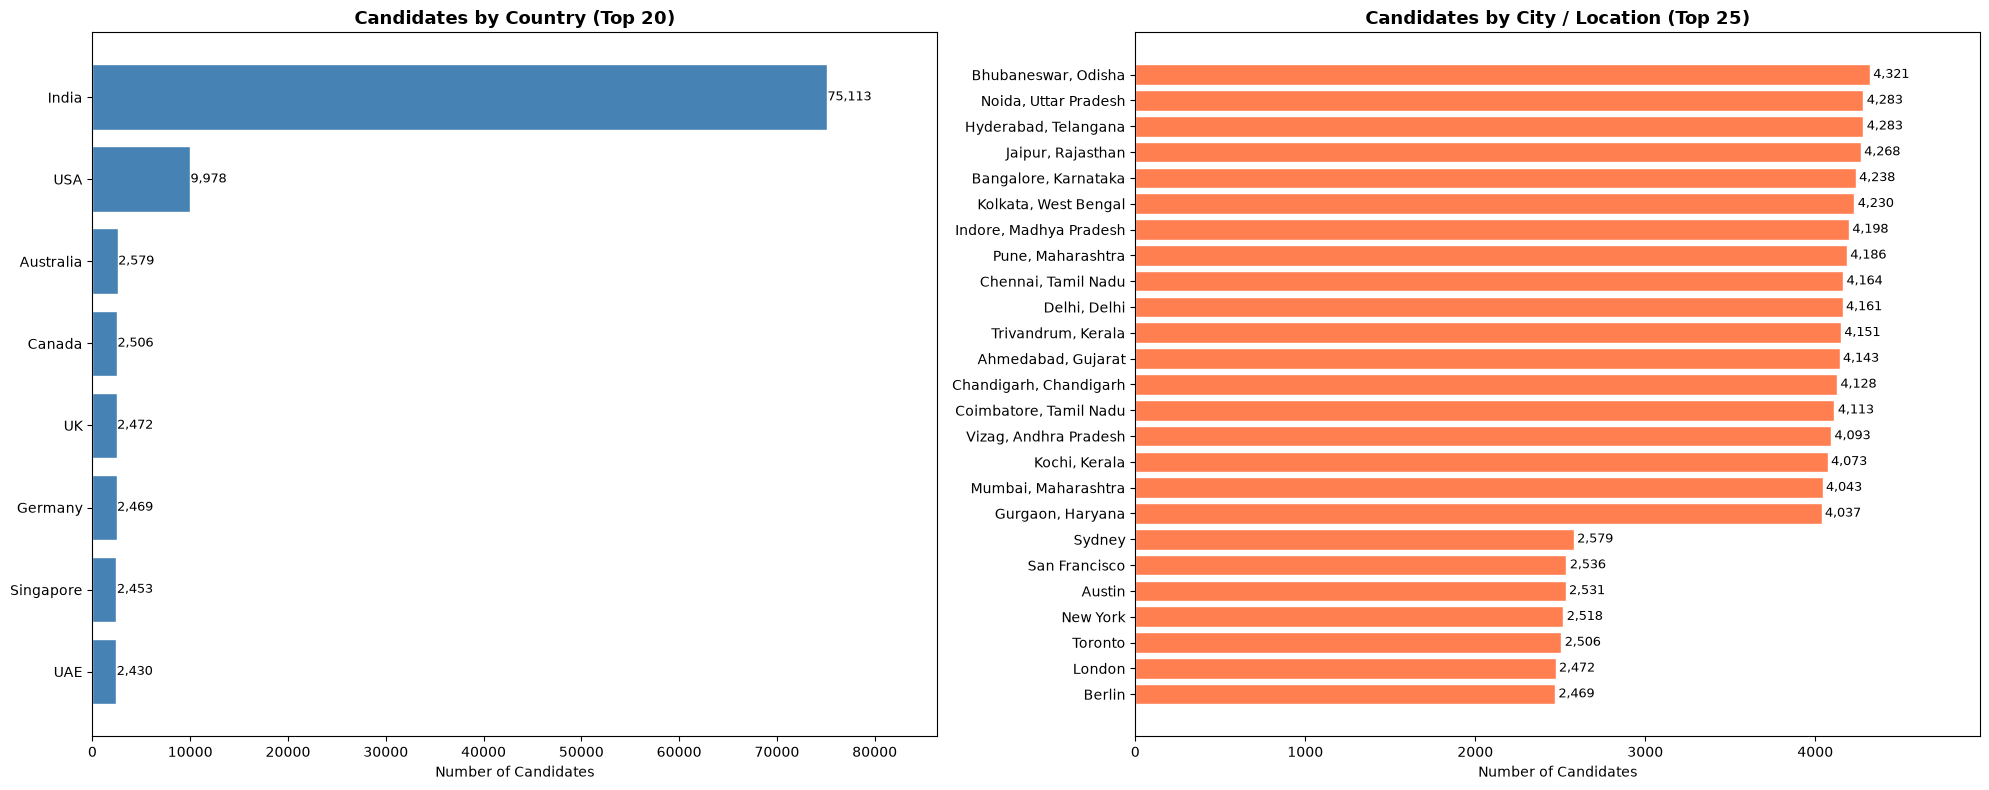


Unique countries : 8
Unique locations : 28


In [21]:
from collections import Counter
import matplotlib.pyplot as plt

country_counts  = Counter(df_locations['country'].str.strip().replace('', 'Unknown'))
location_counts = Counter(df_locations['location'].str.strip().replace('', 'Unknown'))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- Country bar chart ---
top_countries = pd.DataFrame(country_counts.most_common(20), columns=['Country', 'Count'])
bars = axes[0].barh(top_countries['Country'][::-1], top_countries['Count'][::-1],
                    color='steelblue', edgecolor='white')
for bar, val in zip(bars, top_countries['Count'][::-1]):
    axes[0].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_xlabel('Number of Candidates')
axes[0].set_title('Candidates by Country (Top 20)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, top_countries['Count'].max() * 1.15)

# --- City/location bar chart ---
top_locations = pd.DataFrame(location_counts.most_common(25), columns=['Location', 'Count'])
bars2 = axes[1].barh(top_locations['Location'][::-1], top_locations['Count'][::-1],
                     color='coral', edgecolor='white')
for bar, val in zip(bars2, top_locations['Count'][::-1]):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Candidates by City / Location (Top 25)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, top_locations['Count'].max() * 1.15)

plt.tight_layout()
plt.show()

print(f'\nUnique countries : {len(country_counts)}')
print(f'Unique locations : {len(location_counts)}')

From India     : 75,113
Not from India : 24,887
Total          : 100,000


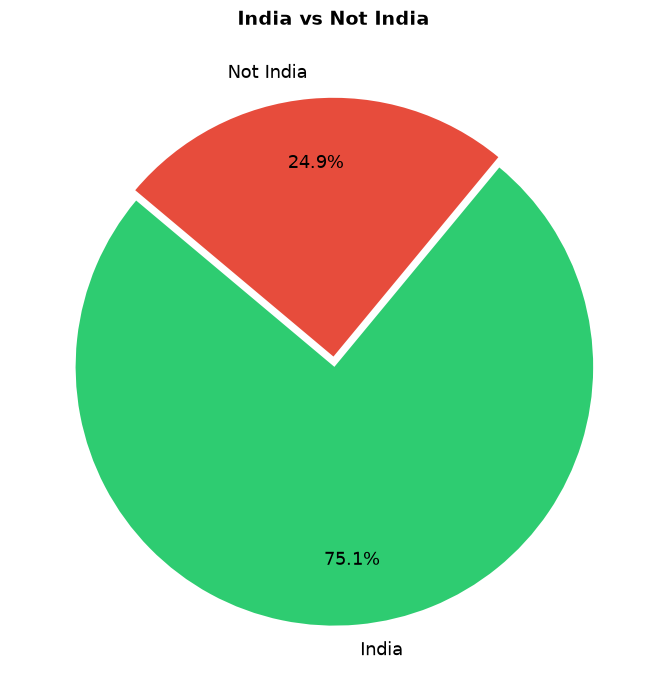

In [25]:
import matplotlib.pyplot as plt

india_mask   = df_locations['country'].str.strip().str.lower() == 'india'
df_india     = df_locations[india_mask].reset_index(drop=True)
df_not_india = df_locations[~india_mask].reset_index(drop=True)

print(f"From India     : {len(df_india):,}")
print(f"Not from India : {len(df_not_india):,}")
print(f"Total          : {len(df_locations):,}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [len(df_india), len(df_not_india)],
    labels=['India', 'Not India'],
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.04, 0),
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 13},
    pctdistance=0.75,
)
ax.set_title('India vs Not India', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Segment breakdown:
  Preferred       : 8,469  (11.3%)
  Welcome         : 16,524  (22.0%)
  Rest of India   : 50,120  (66.7%)


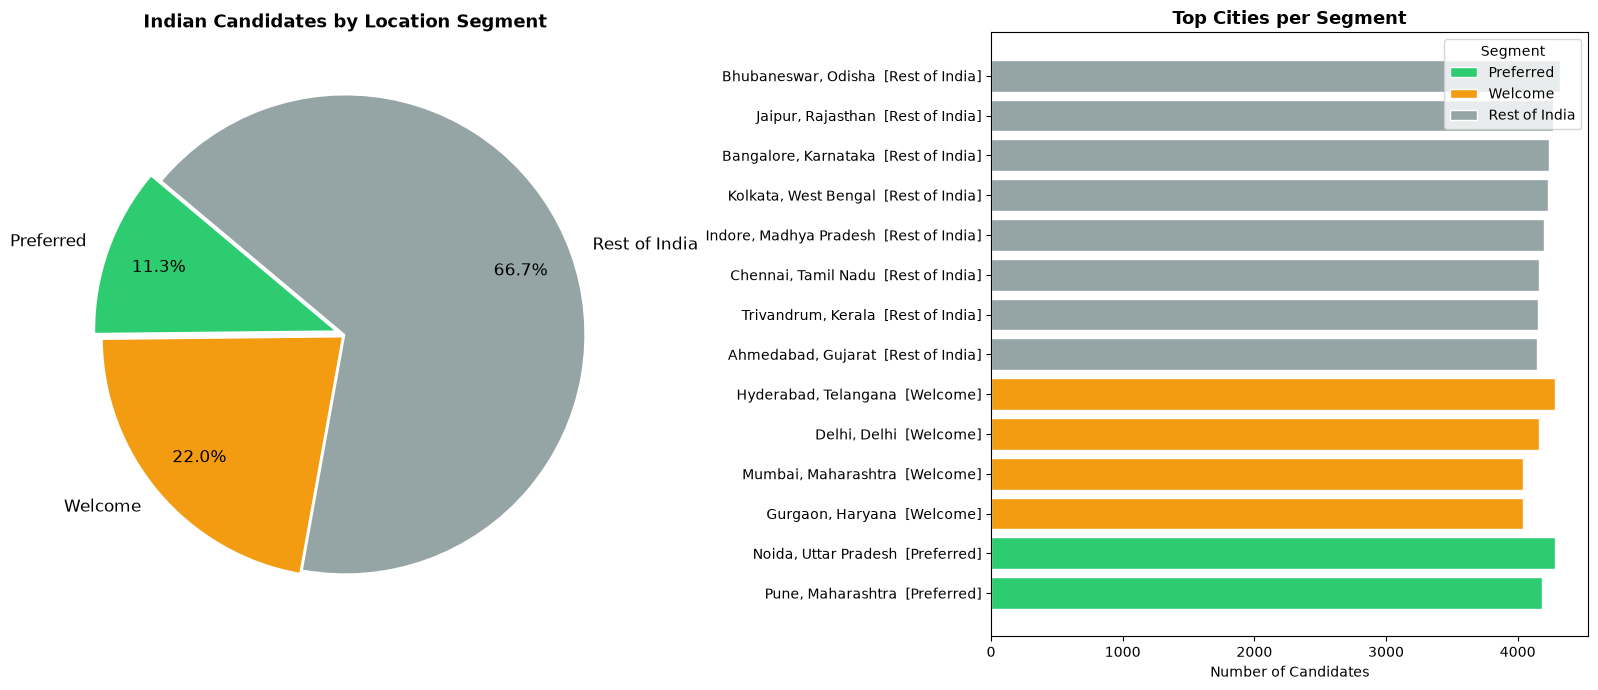

In [27]:
import matplotlib.pyplot as plt

PREFERRED = ['pune', 'noida']
WELCOME     = ['mumbai', 'delhi', 'hyderabad', 'gurgaon']

def location_segment(loc):
    l = (loc or '').lower()
    if any(city in l for city in PREFERRED):
        return 'Preferred'
    if any(city in l for city in WELCOME):
        return 'Welcome'
    return 'Rest of India'

df_india_seg = df_india.copy()
df_india_seg['segment'] = df_india_seg['location'].apply(location_segment)

seg_counts = df_india_seg['segment'].value_counts().reindex(['Preferred', 'Welcome', 'Rest of India'])

print("Segment breakdown:")
for seg, cnt in seg_counts.items():
    print(f"  {seg:<16}: {cnt:,}  ({100*cnt/len(df_india_seg):.1f}%)")

# --- Side-by-side: pie + stacked bar by top cities ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Pie
colors = {'Preferred': '#2ecc71', 'Welcome': '#f39c12', 'Rest of India': '#95a5a6'}
axes[0].pie(
    seg_counts,
    labels=seg_counts.index,
    colors=[colors[s] for s in seg_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    explode=(0.05, 0.02, 0),
    textprops={'fontsize': 12},
    pctdistance=0.78,
)
axes[0].set_title('Indian Candidates by Location Segment', fontsize=13, fontweight='bold')

# Top cities within each segment
top_cities = (
    df_india_seg.groupby(['segment', 'location'])
    .size()
    .reset_index(name='count')
    .sort_values(['segment', 'count'], ascending=[True, False])
)

for seg, color in colors.items():
    subset = top_cities[top_cities['segment'] == seg].head(8)
    axes[1].barh(
        subset['location'][::-1] + f'  [{seg}]',
        subset['count'][::-1],
        color=color, edgecolor='white', label=seg
    )

axes[1].set_xlabel('Number of Candidates')
axes[1].set_title('Top Cities per Segment', fontsize=13, fontweight='bold')
axes[1].legend(title='Segment', fontsize=10)
plt.tight_layout()
plt.show() 

<h3> Inspecting Candidate Notice Periods </h3>

In [31]:
import matplotlib.pyplot as plt

# Extract candidate_id and notice_period_days from redrob_signals
df_notice = pd.DataFrame([
    {
        'candidate_id'       : c.get('candidate_id', ''),
        'notice_period_days' : (c.get('redrob_signals', {}) or {}).get('notice_period_days'),
    }
    for c in records
]).sort_values('candidate_id').reset_index(drop=True)

df_notice['notice_period_days'] = pd.to_numeric(df_notice['notice_period_days'], errors='coerce')

def notice_group(days):
    if pd.isna(days):
        return 'Unknown'
    return 'Up to 30 days' if days <= 30 else '> 30 days'

df_notice['group'] = df_notice['notice_period_days'].apply(notice_group)

group_counts = df_notice['group'].value_counts().reindex(['Up to 30 days', '> 30 days', 'Unknown'])

print("Notice period breakdown:")
for grp, cnt in group_counts.items():
    print(f"  {grp:<16}: {cnt:,}  ({100 * cnt / len(df_notice):.1f}%)")


Notice period breakdown:
  Up to 30 days   : 13,809.0  (13.8%)
  > 30 days       : 86,191.0  (86.2%)
  Unknown         : nan  (nan%)
